## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [5]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [6]:
def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [7]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(
    model,
    epochs=500,
    lr_schedule=1e-3,
    optimizer="Adam",
    title="Learning Curves",
    batch_size=64,  # kept for API compatibility; ignored if datasets are batched
    use_early_stopping=True,
    patience=8,
    min_delta=1e-4,
    callbacks=None,
    verbose=1,
    return_history=False,
):
    print(f"\n{title}\n")

    # Choose optimizer
    with tf.device('/CPU:0'): # Force optimizer creation on CPU
        if optimizer == "Adam":
            opt = Adam(learning_rate=lr_schedule)
        else:
            opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose,
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=cbs, verbose=verbose)

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history

### Load the Intel Image Classification Dataset  



In [8]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

100%|██████████| 346M/346M [00:01<00:00, 207MB/s]

Extracting files...


In [9]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 1.0

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)

        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    Forces dataset operations onto CPU to avoid CUDA initialization conflicts.
    """
    with tf.device('/CPU:0'):
        ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

        if shuffle:
            # shuffle file *references* (cheap), not image tensors
            ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

        def _load_and_preprocess(path, label):
            # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
            img_bytes = tf.io.read_file(path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, img_size, method="bilinear")
            img = tf.cast(img, tf.float32)
            img = preprocess_input(img)
            return img, label

        ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

        if cache_to_disk is not None:
            ds = ds.cache(cache_to_disk)

        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed

# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets on CPU to prevent CUDA runtime driver issues
with tf.device('/CPU:0'):
    train_ds = make_image_dataset(
        files_train,
        y_train,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        cache_to_disk=None,
    )

    val_ds = make_image_dataset(
        files_val,
        y_val,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        cache_to_disk=None,
    )

    # 5) Test set
    test_files, test_labels, _ = list_files_and_labels(
        test_dir,
        class_names=class_names,
    )

    # Use the same fraction for quick development runs
    test_files, test_labels = stratified_subsample(
        test_files,
        test_labels,
        fraction=DATA_FRACTION,
        seed=SEED,
    )

    test_ds = make_image_dataset(
        test_files,
        test_labels,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        cache_to_disk=None,
    )

### Examine The Dataset

In [10]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


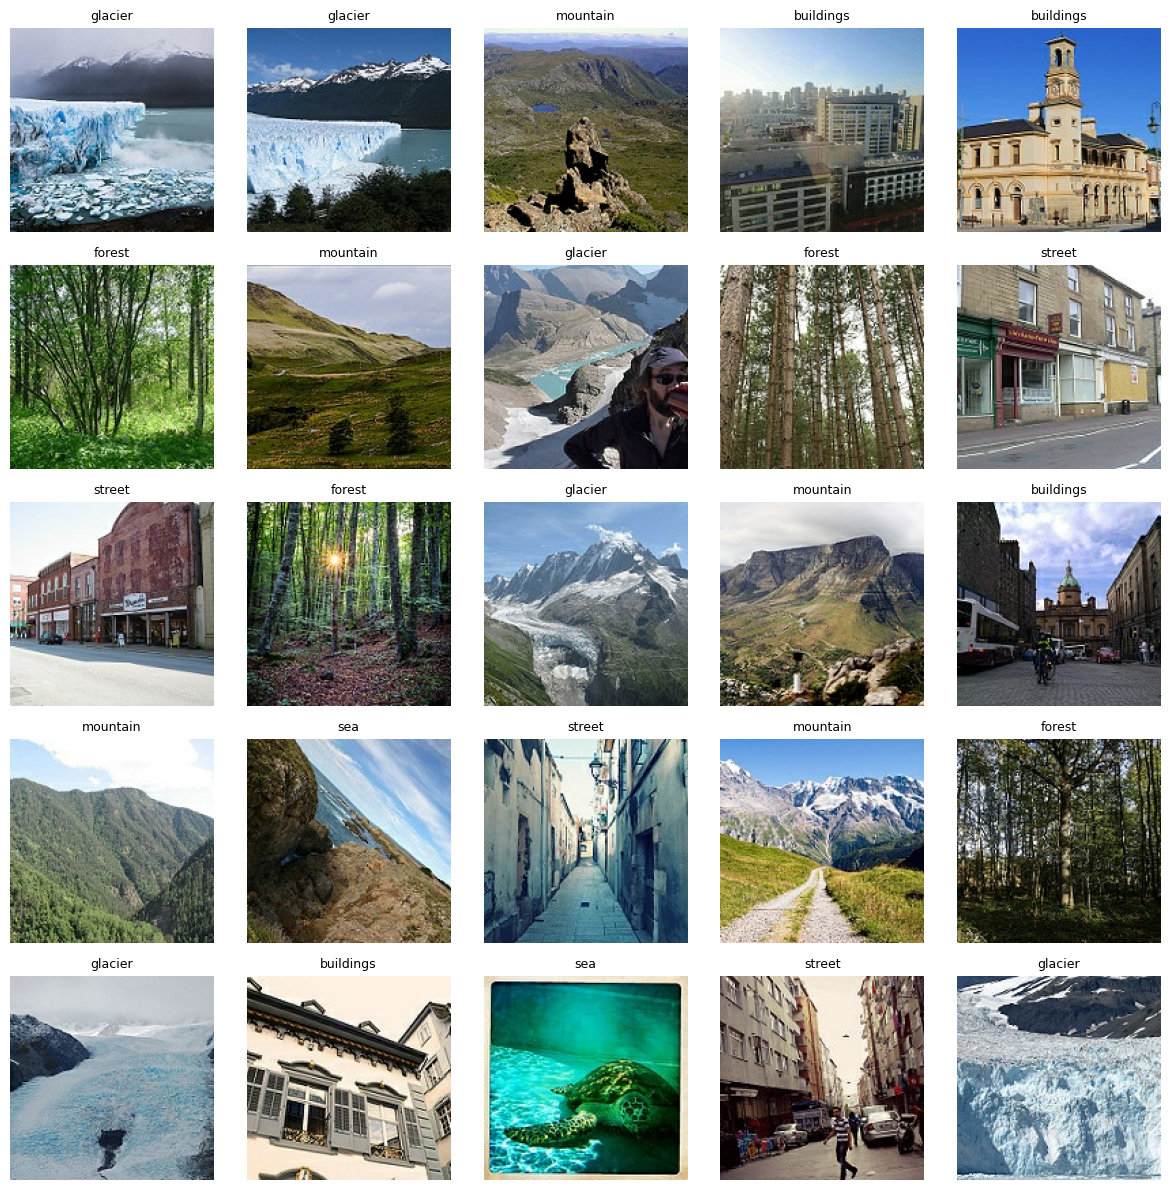

In [11]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
    img = (images[i].numpy() + 1.0) / 2.0

    plt.imshow(img)
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [12]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [14]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    with tf.device('/CPU:0'):
        base = mobilenet_v2.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=INPUT_SHAPE,
            pooling="avg",
        )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/tmp/ipykernel_8140/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [11]:
# Ha, this is very long!

base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

/tmp/ipykernel_8140/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 55s 152ms/step - accuracy: 0.8573 - loss: 0.3946 - val_accuracy: 0.8934 - val_loss: 0.3059
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9080 - loss: 0.2485 - val_accuracy: 0.9019 - val_loss: 0.2770
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9201 - loss: 0.2143 - val_accuracy: 0.8934 - val_loss: 0.3061
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9255 - loss: 0.1941 - val_accuracy: 0.8998 - val_loss: 0.2763
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9351 - loss: 0.1748 - val_accuracy: 0.8852 - val_loss: 0.3452
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9379 - loss: 0.1640 - val_accuracy: 0.8944 - val_loss: 0.3081
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9407 - loss: 0.1533 - val_accuracy: 0.8948 - val_loss: 0.3066
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - a

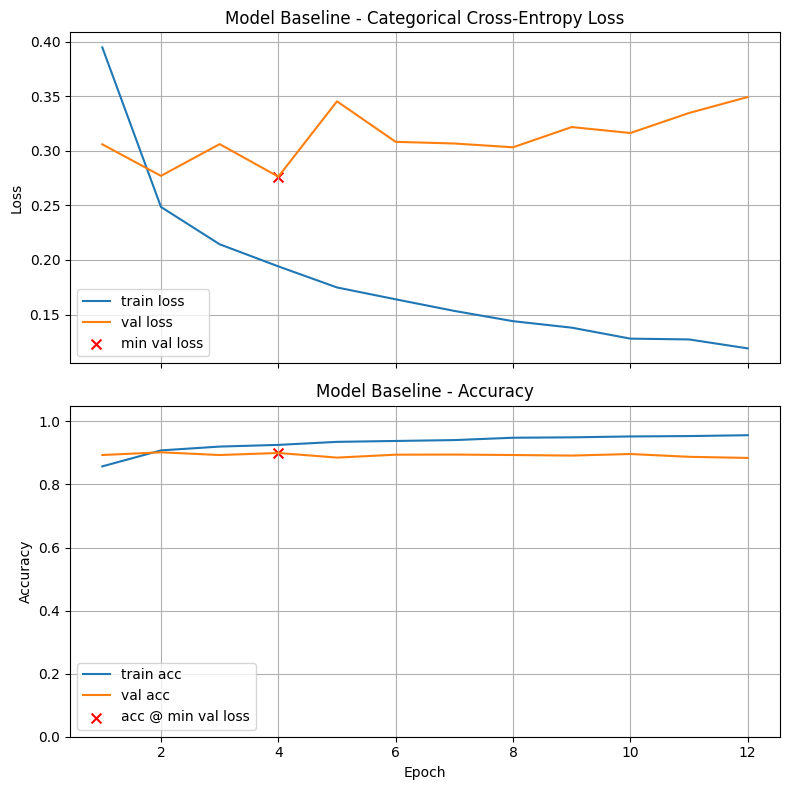

Final Training Loss:            0.1190
Final Training Accuracy:        0.9562
Final Validation Loss:          0.3492
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.2763 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8998

Test Loss: 0.2550
Test Accuracy: 0.9003

Validation-Test Gap (accuracy): 0.000547

Execution Time: 00:10:35


In [15]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

with tf.device('/CPU:0'): # Ensure Sequential model and layers are created on CPU
    model_baseline = models.Sequential([
        base_model,
        Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
    ])

with tf.device('/CPU:0'): # Ensure training also runs on CPU
    train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



## Problem 1: Redesigning the Classification Head

For Problem 1, we keep the MobileNetV2 backbone frozen and focus on improving the classification head. Here are three distinct head architectures designed to go beyond the baseline single-layer dense head.

### Design 1: Dropout Regularization

This design uses two `Dense` layers with `ReLU` activations, separated by `Dropout` layers. The `Dropout` layers help prevent overfitting by randomly setting a fraction of input units to zero at each update during training, which forces the network to learn more robust features. We will experiment with different dropout rates and learning rates.


HEAD DESIGN 1: Dropout-Based Head


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Design 1.1: Dropout (high) | LR=1e-3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.8277 - loss: 0.4901 - val_accuracy: 0.9051 - val_loss: 0.2817
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8826 - loss: 0.3231 - val_accuracy: 0.9080 - val_loss: 0.2723
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8953 - loss: 0.2874 - val_accuracy: 0.9105 - val_loss: 0.2624
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9039 - loss: 0.2684 - val_accuracy: 0.9062 - val_loss: 0.2625
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9107 - loss: 0.2509 - val_accuracy: 0.9094 - val_loss: 0.2555
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9154 - loss: 0.2305 - val_accuracy: 0.8991 - val_loss: 0.2821
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9209 - loss: 0.2171 - val_accuracy: 0.9069 - val_loss: 0.2742
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━

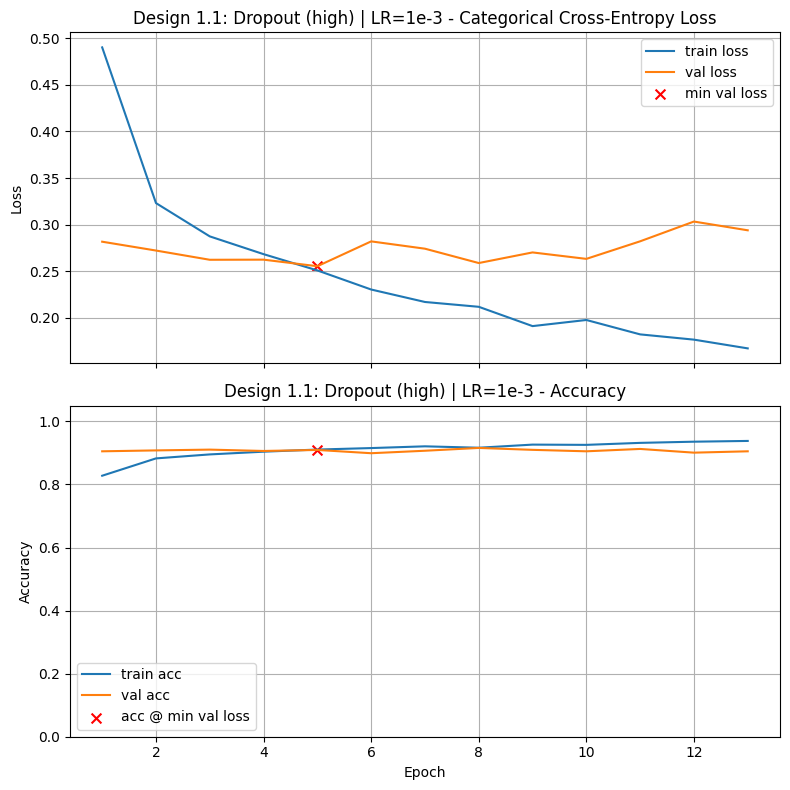

Final Training Loss:            0.1674
Final Training Accuracy:        0.9380
Final Validation Loss:          0.2940
Final Validation Accuracy:      0.9051
Minimum Validation Loss:        0.2555 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9094

Test Loss: 0.2369
Test Accuracy: 0.9093

Validation-Test Gap (accuracy): 0.000082

Execution Time: 00:11:33

Design 1.2: Dropout (moderate) | LR=5e-4

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 153ms/step - accuracy: 0.8536 - loss: 0.4049 - val_accuracy: 0.8834 - val_loss: 0.3209
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8970 - loss: 0.2725 - val_accuracy: 0.9044 - val_loss: 0.2720
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9146 - loss: 0.2292 - val_accuracy: 0.8987 - val_loss: 0.2836
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9240 - loss: 0.2002 - val_accuracy: 0.9058 - val_loss: 0.2658
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9302 -

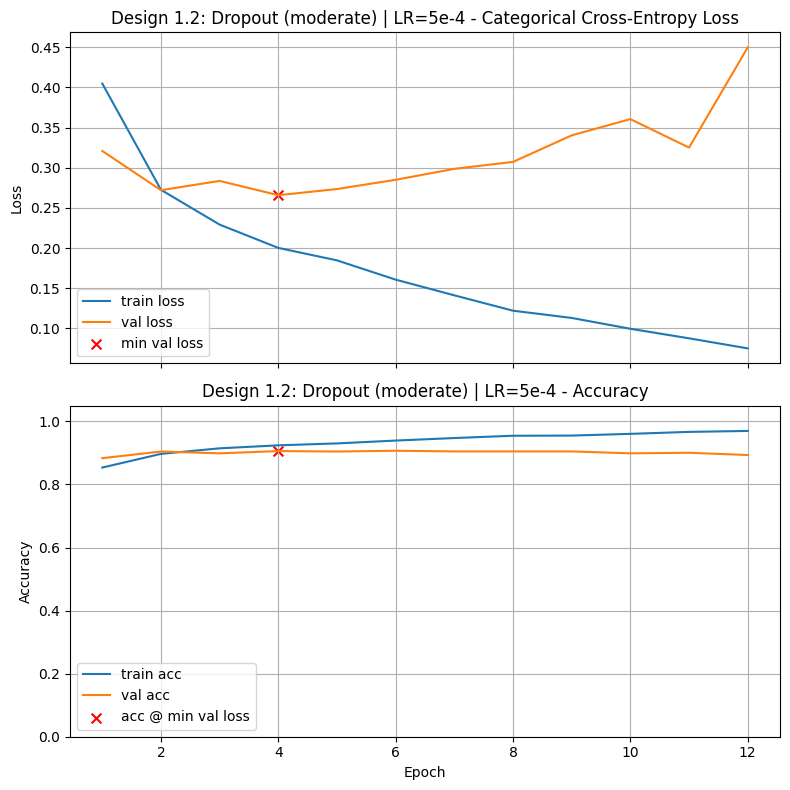

Final Training Loss:            0.0750
Final Training Accuracy:        0.9697
Final Validation Loss:          0.4499
Final Validation Accuracy:      0.8934
Minimum Validation Loss:        0.2658 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9058

Test Loss: 0.2262
Test Accuracy: 0.9123

Validation-Test Gap (accuracy): 0.006485

Execution Time: 00:10:41

Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 153ms/step - accuracy: 0.8527 - loss: 0.4094 - val_accuracy: 0.9001 - val_loss: 0.2897 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8979 - loss: 0.2799 - val_accuracy: 0.8998 - val_loss: 0.2828 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9102 - loss: 0.2411 - val_accuracy: 0.8951 - val_loss: 0.2923 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9191 - loss: 0.2198 - val_accuracy: 0.9058 - val_

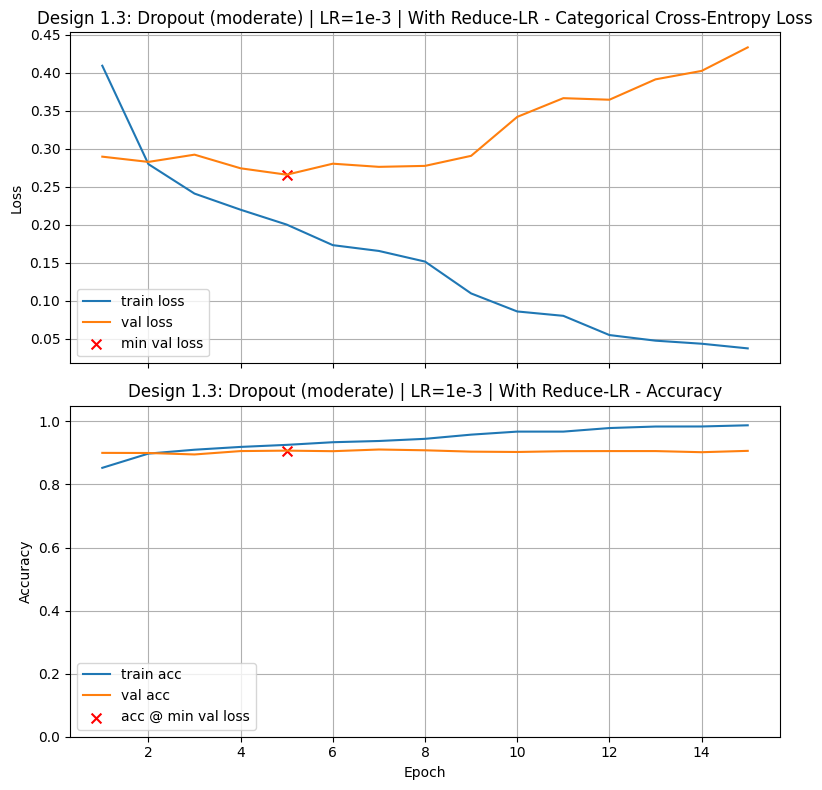

Final Training Loss:            0.0373
Final Training Accuracy:        0.9876
Final Validation Loss:          0.4335
Final Validation Accuracy:      0.9066
Minimum Validation Loss:        0.2659 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9073

Test Loss: 0.2472
Test Accuracy: 0.9103

Validation-Test Gap (accuracy): 0.003058

Execution Time: 00:13:18


In [13]:
print("="*80)
print("HEAD DESIGN 1: Dropout-Based Head")
print("="*80)

# Experiment 1.1: High dropout, moderate learning rate
base_1_1 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_1_1 = models.Sequential([
        base_1_1,
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    train_and_test(model_1_1,
                   lr_schedule=1e-3,
                   title="Design 1.1: Dropout (high) | LR=1e-3")

# Experiment 1.2: Moderate dropout, lower learning rate
base_1_2 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_1_2 = models.Sequential([
        base_1_2,
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    train_and_test(model_1_2,
                   lr_schedule=5e-4,
                   title="Design 1.2: Dropout (moderate) | LR=5e-4")

# Experiment 1.3: Moderate dropout with ReduceLROnPlateau
base_1_3 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_1_3 = models.Sequential([
        base_1_3,
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_1_3 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_1_3,
                   lr_schedule=1e-3,
                   callbacks=[reduce_lr_1_3],
                   patience=10,
                   title="Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR")

### Design 2: Batch Normalization + Dropout

This design incorporates `BatchNormalization` layers after each `Dense` layer (before activation) in addition to `Dropout`. Batch Normalization helps stabilize training by normalizing the activations of the previous layer, reducing the internal covariate shift. It also acts as a mild regularizer, potentially allowing for less aggressive dropout rates. We will explore its impact on training stability and performance.


HEAD DESIGN 2: Batch Normalization + Dropout


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Design 2.1: BatchNorm + Dropout | LR=1e-3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 154ms/step - accuracy: 0.8679 - loss: 0.3686 - val_accuracy: 0.8912 - val_loss: 0.2866
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9102 - loss: 0.2471 - val_accuracy: 0.9091 - val_loss: 0.2544
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9290 - loss: 0.1975 - val_accuracy: 0.8951 - val_loss: 0.2794
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9329 - loss: 0.1713 - val_accuracy: 0.8994 - val_loss: 0.2825
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9476 - loss: 0.1376 - val_accuracy: 0.8902 - val_loss: 0.3304
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9525 - loss: 0.1189 - val_accuracy: 0.8994 - val_loss: 0.3010
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9578 - loss: 0.1113 - val_accuracy: 0.9009 - val_loss: 0.3226
Epoch 8/500
351/351 ━━━━━━━━━━━━

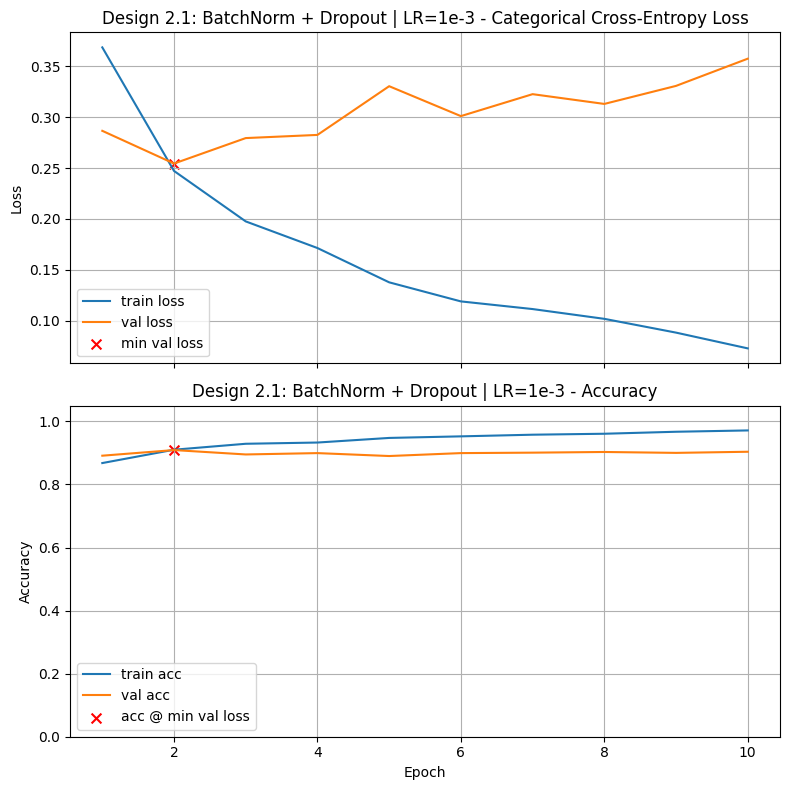

Final Training Loss:            0.0727
Final Training Accuracy:        0.9713
Final Validation Loss:          0.3575
Final Validation Accuracy:      0.9037
Minimum Validation Loss:        0.2544 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9091

Test Loss: 0.2517
Test Accuracy: 0.9073

Validation-Test Gap (accuracy): 0.001725

Execution Time: 00:08:58

Design 2.2: BatchNorm + Light Dropout | LR=1e-3 | With Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.8740 - loss: 0.3444 - val_accuracy: 0.8984 - val_loss: 0.2823 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9169 - loss: 0.2206 - val_accuracy: 0.8984 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9326 - loss: 0.1768 - val_accuracy: 0.9005 - val_loss: 0.3104 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9426 - loss: 0.1443 - val_accuracy: 0.8927

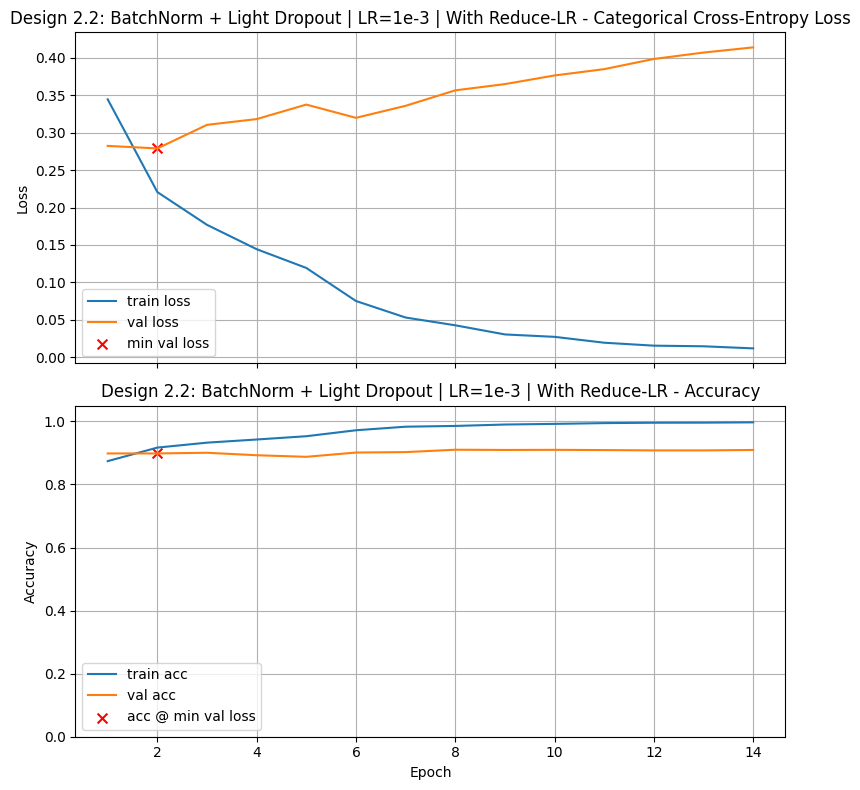

Final Training Loss:            0.0118
Final Training Accuracy:        0.9970
Final Validation Loss:          0.4139
Final Validation Accuracy:      0.9094
Minimum Validation Loss:        0.2789 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8984

Test Loss: 0.2763
Test Accuracy: 0.9027

Validation-Test Gap (accuracy): 0.004307

Execution Time: 00:12:26

Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.8557 - loss: 0.4313 - val_accuracy: 0.8984 - val_loss: 0.2750 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9027 - loss: 0.2729 - val_accuracy: 0.9037 - val_loss: 0.2640 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9173 - loss: 0.2295 - val_accuracy: 0.9119 - val_loss: 0.2560 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9282 - loss: 0.1970 - val_accuracy: 

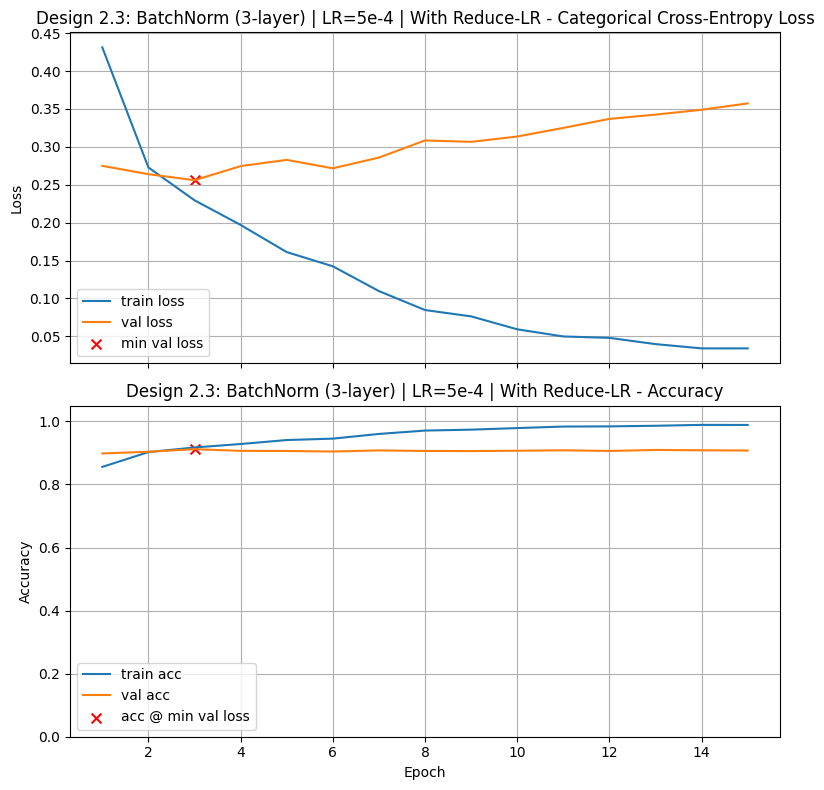

Final Training Loss:            0.0341
Final Training Accuracy:        0.9887
Final Validation Loss:          0.3574
Final Validation Accuracy:      0.9076
Minimum Validation Loss:        0.2560 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9119

Test Loss: 0.2278
Test Accuracy: 0.9157

Validation-Test Gap (accuracy): 0.003755

Execution Time: 00:13:19


In [14]:
print("\n" + "="*80)
print("HEAD DESIGN 2: Batch Normalization + Dropout")
print("="*80)

# Experiment 2.1: BatchNorm with moderate dropout, standard learning rate
base_2_1 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_2_1 = models.Sequential([
        base_2_1,
        Dense(512, activation=None),  # No activation before BatchNorm
        BatchNormalization(),
        ReLU(),
        Dropout(0.3),
        Dense(256, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    train_and_test(model_2_1,
                   lr_schedule=1e-3,
                   title="Design 2.1: BatchNorm + Dropout | LR=1e-3")

# Experiment 2.2: BatchNorm with lighter dropout and ReduceLROnPlateau
base_2_2 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_2_2 = models.Sequential([
        base_2_2,
        Dense(512, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),
        Dense(256, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_2_2 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_2_2,
                   lr_schedule=1e-3,
                   callbacks=[reduce_lr_2_2],
                   patience=12,
                   title="Design 2.2: BatchNorm + Light Dropout | LR=1e-3 | With Reduce-LR")

# Experiment 2.3: BatchNorm with deeper structure
base_2_3 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_2_3 = models.Sequential([
        base_2_3,
        Dense(512, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.3),
        Dense(256, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),
        Dense(128, activation=None),
        BatchNormalization(),
        ReLU(),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_2_3 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_2_3,
                   lr_schedule=5e-4,
                   callbacks=[reduce_lr_2_3],
                   patience=12,
                   title="Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR")

### Design 3: L2 Regularization + Dense Layers

This design explores `L2` kernel regularization on the `Dense` layers. L2 regularization (also known as weight decay) adds a penalty to the loss function that is proportional to the square of the magnitude of the weights. This encourages the model to use smaller weights, which can prevent overfitting and improve generalization. We will vary the L2 regularization strength and combine it with dropout.


HEAD DESIGN 3: L2 Regularization


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Design 3.1: L2 Regularization | LR=1e-3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 154ms/step - accuracy: 0.8496 - loss: 0.5149 - val_accuracy: 0.8941 - val_loss: 0.3857
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8964 - loss: 0.3798 - val_accuracy: 0.8887 - val_loss: 0.3995
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9099 - loss: 0.3370 - val_accuracy: 0.8994 - val_loss: 0.3601
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9183 - loss: 0.3088 - val_accuracy: 0.9105 - val_loss: 0.3435
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9260 - loss: 0.2838 - val_accuracy: 0.8894 - val_loss: 0.3716
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9240 - loss: 0.2768 - val_accuracy: 0.9076 - val_loss: 0.3556
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9339 - loss: 0.2526 - val_accuracy: 0.9069 - val_loss: 0.3770
Epoch 8/500
351/351 ━━━━━━━━━━━━━━

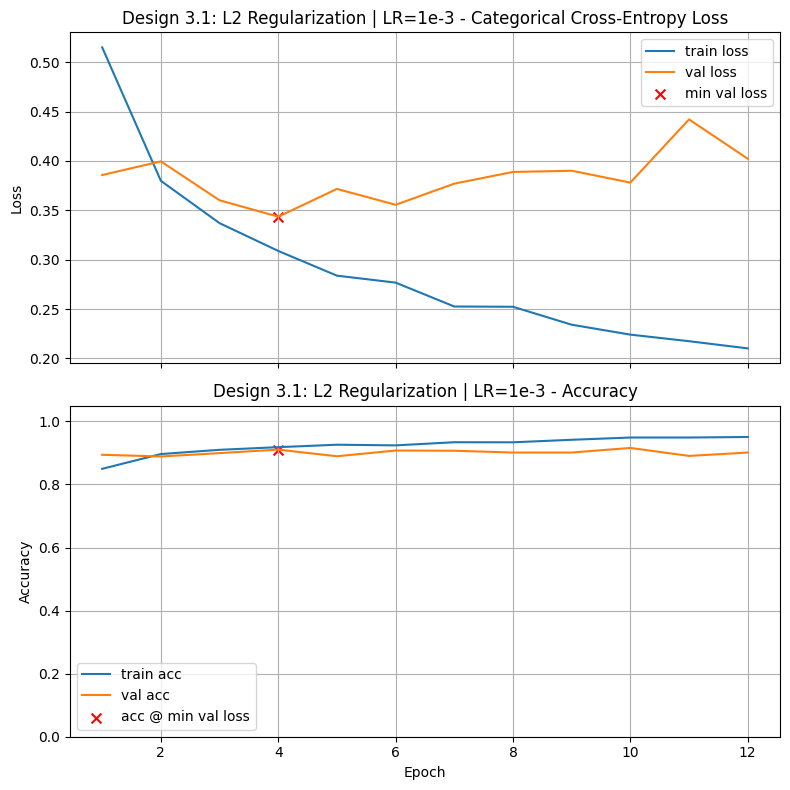

Final Training Loss:            0.2102
Final Training Accuracy:        0.9505
Final Validation Loss:          0.4022
Final Validation Accuracy:      0.9012
Minimum Validation Loss:        0.3435 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9105

Test Loss: 0.3205
Test Accuracy: 0.9087

Validation-Test Gap (accuracy): 0.001818

Execution Time: 00:10:41

Design 3.2: L2 (lighter) | LR=1e-3 | With Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.8600 - loss: 0.4402 - val_accuracy: 0.8948 - val_loss: 0.3511 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9028 - loss: 0.3224 - val_accuracy: 0.8869 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9139 - loss: 0.2824 - val_accuracy: 0.8980 - val_loss: 0.3447 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9234 - loss: 0.2602 - val_accuracy: 0.9012 - val_loss: 

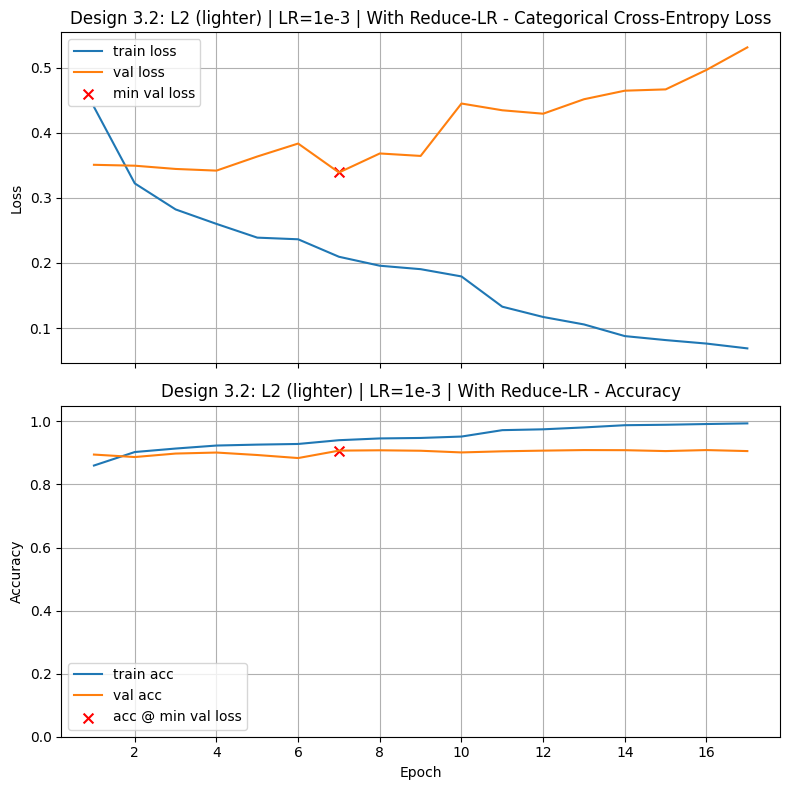

Final Training Loss:            0.0687
Final Training Accuracy:        0.9937
Final Validation Loss:          0.5317
Final Validation Accuracy:      0.9058
Minimum Validation Loss:        0.3392 (Epoch 7)
Validation Accuracy @ Min Loss: 0.9073

Test Loss: 0.3115
Test Accuracy: 0.9103

Validation-Test Gap (accuracy): 0.003058

Execution Time: 00:15:01

Design 3.3: L2 (3-layer) | LR=5e-4

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.8441 - loss: 0.5569 - val_accuracy: 0.8927 - val_loss: 0.4169
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.8980 - loss: 0.4049 - val_accuracy: 0.9058 - val_loss: 0.3841
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9106 - loss: 0.3671 - val_accuracy: 0.9083 - val_loss: 0.3761
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9179 - loss: 0.3330 - val_accuracy: 0.9101 - val_loss: 0.3708
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9280 - loss:

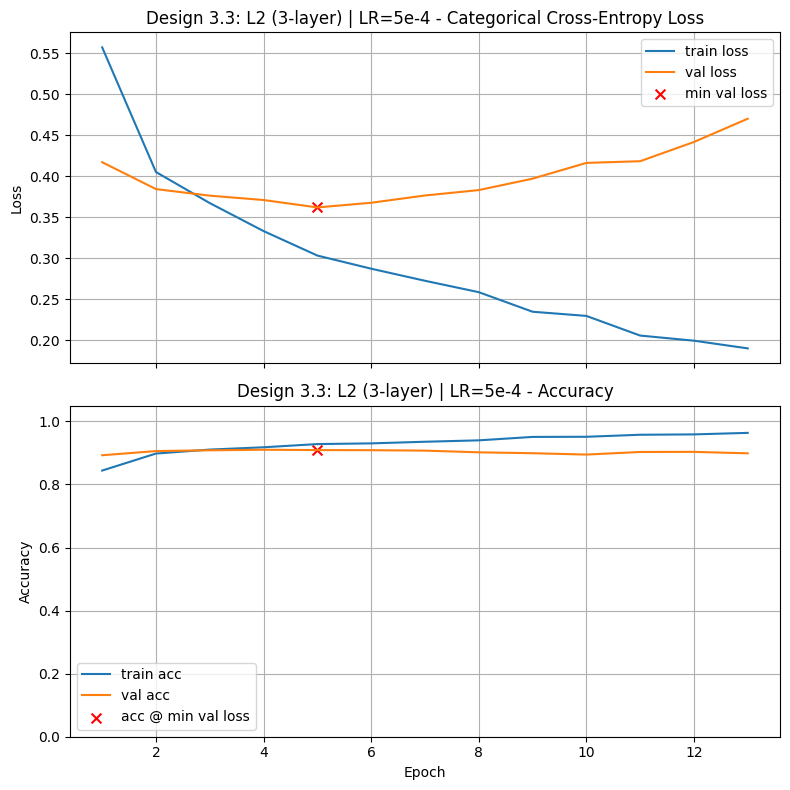

Final Training Loss:            0.1900
Final Training Accuracy:        0.9636
Final Validation Loss:          0.4699
Final Validation Accuracy:      0.8987
Minimum Validation Loss:        0.3618 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9091

Test Loss: 0.3390
Test Accuracy: 0.9093

Validation-Test Gap (accuracy): 0.000275

Execution Time: 00:11:34


In [15]:
print("\n" + "="*80)
print("HEAD DESIGN 3: L2 Regularization")
print("="*80)

# Experiment 3.1: L2 with moderate dropout
base_3_1 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_3_1 = models.Sequential([
        base_3_1,
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.3),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    train_and_test(model_3_1,
                   lr_schedule=1e-3,
                   title="Design 3.1: L2 Regularization | LR=1e-3")

# Experiment 3.2: L2 with ReduceLROnPlateau and different L2 strength
base_3_2 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_3_2 = models.Sequential([
        base_3_2,
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-5)),
        Dropout(0.25),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-5)),
        Dropout(0.15),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_3_2 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_3_2,
                   lr_schedule=1e-3,
                   callbacks=[reduce_lr_3_2],
                   patience=10,
                   title="Design 3.2: L2 (lighter) | LR=1e-3 | With Reduce-LR")

# Experiment 3.3: L2 with three layers
base_3_3 = make_base_model_pooled(trainable=False)
with tf.device('/CPU:0'):
    model_3_3 = models.Sequential([
        base_3_3,
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.3),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    train_and_test(model_3_3,
                   lr_schedule=5e-4,
                   title="Design 3.3: L2 (3-layer) | LR=5e-4")

In [17]:
print("\n" + "="*80)
print("SUMMARY: VALIDATION ACCURACY RANKING (Problem 1 experiments)")
print("="*80)
print_results()


SUMMARY: VALIDATION ACCURACY RANKING (Problem 1 experiments)
Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR	0.9119	3
Design 3.1: L2 Regularization | LR=1e-3 	0.9105	4
Design 1.1: Dropout (high) | LR=1e-3    	0.9094	5
Design 2.1: BatchNorm + Dropout | LR=1e-3	0.9091	2
Design 3.3: L2 (3-layer) | LR=5e-4      	0.9091	5
Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR	0.9073	5
Design 3.2: L2 (lighter) | LR=1e-3 | With Reduce-LR	0.9073	7
Design 1.2: Dropout (moderate) | LR=5e-4	0.9058	4
Model Baseline                          	0.9026	5
Design 2.2: BatchNorm + Light Dropout | LR=1e-3 | With Reduce-LR	0.8984	2

SUMMARY: VALIDATION ACCURACY RANKING (Problem 1 experiments)
Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR	0.9119	3
Design 3.1: L2 Regularization | LR=1e-3 	0.9105	4
Design 1.1: Dropout (high) | LR=1e-3    	0.9094	5
Design 2.1: BatchNorm + Dropout | LR=1e-3	0.9091	2
Design 3.3: L2 (3-layer) | LR=5e-4      	0.9091	5
Design 1.3: Dropout (moderate) | LR=

# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points.

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

> For Problem 1, the best-performing head architecture was 'Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR', achieving a validation accuracy of 0.9119. This design featured a deeper, three-layer dense head, incorporated Batch Normalization after each dense layer, and utilized ReduceLROnPlateau with a moderately low learning rate of 5e-4. Compared to simpler heads with only Dropout (Design 1.x) or L2 regularization (Design 3.x), the combination of increased head depth, Batch Normalization for training stability, and adaptive learning rate scheduling proved most effective. These experiments suggest that even when the backbone is frozen, a sophisticated, deeper, and well-regularized classification head, coupled with careful learning rate management, can significantly enhance model performance and stability.

**Validation Accuracy here (15 pts):**

In [18]:
# Set a1 to the validation accuracy found by your best model for this problem.

a1 = 0.9119

In [19]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem

print(f'a1 = {a1:.4f}')


a1 = 0.9119


In [20]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_dir = '/content/drive/MyDrive/703/Code'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoints will be salved to: {checkpoint_dir}")

Mounted at /content/drive
Checkpoints will be salved to: /content/drive/MyDrive/703/Code


In [21]:
import tensorflow as tf

checkpoint_path = f"{checkpoint_dir}/cp-epoch-{{epoch:02d}}.weights.h5"

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1,
    save_freq='epoch'
)

# Pass callback to model.fit
# model.fit(train_dataset, epochs=10, callbacks=[cp_callback]) # This line assumes `model` and `train_dataset` are defined.

## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



## Problem 2: Fully Trainable Backbone Experiments

For Problem 2, we will use the best performing head architecture from Problem 1, which was 'Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR'. We will now make the entire MobileNetV2 backbone trainable and experiment with appropriately small learning rates and `ReduceLROnPlateau` to find a good configuration for fine-tuning.

PROBLEM 2: FULLY TRAINABLE BACKBONE


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2.1: Full Trainable | LR=3e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 565ms/step - accuracy: 0.7107 - loss: 0.8120 - val_accuracy: 0.8477 - val_loss: 0.4193 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.8841 - loss: 0.3357 - val_accuracy: 0.8766 - val_loss: 0.3626 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 551ms/step - accuracy: 0.9167 - loss: 0.2470 - val_accuracy: 0.9173 - val_loss: 0.2497 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.9314 - loss: 0.1951 - val_accuracy: 0.9205 - val_loss: 0.2456 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.9470 - loss: 0.1502 - val_accuracy: 0.9226 - val_loss: 0.2527 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 551ms/step - accuracy: 0.9599 - loss: 0.1185 - val_accuracy: 0.9251 - val_loss: 0.2525 - learning_rate: 

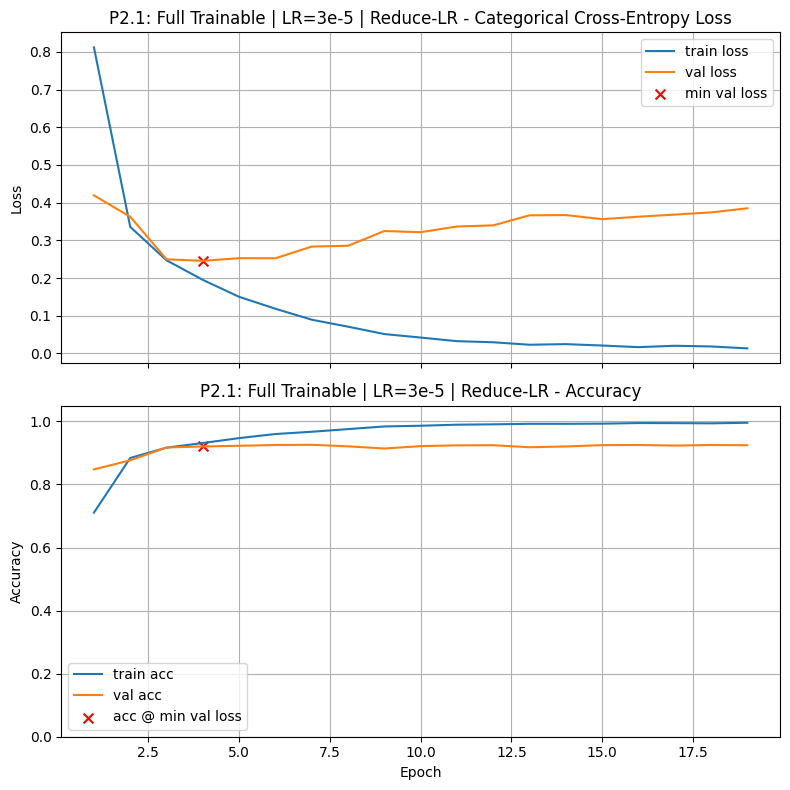

Final Training Loss:            0.0134
Final Training Accuracy:        0.9956
Final Validation Loss:          0.3850
Final Validation Accuracy:      0.9244
Minimum Validation Loss:        0.2456 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9205

Test Loss: 0.2309
Test Accuracy: 0.9203

Validation-Test Gap (accuracy): 0.000137

Execution Time: 01:01:40


In [22]:
print("="*80)
print("PROBLEM 2: FULLY TRAINABLE BACKBONE")
print("="*80)

# Experiment 2.1: Fully trainable backbone with small learning rate and ReduceLROnPlateau
base_2_1_full = make_base_model_pooled(trainable=True)
with tf.device('/CPU:0'):
    model_2_1_full = models.Sequential([
        base_2_1_full,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_2_1_full = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5, # Increased patience for finer tuning
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_2_1_full,
                   lr_schedule=3e-5, # Small learning rate for fine-tuning backbone
                   callbacks=[reduce_lr_2_1_full],
                   patience=15, # Increased patience for EarlyStopping
                   title="P2.1: Full Trainable | LR=3e-5 | Reduce-LR")

/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2.2: Full Trainable | LR=1e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 209s 563ms/step - accuracy: 0.5071 - loss: 1.3055 - val_accuracy: 0.8274 - val_loss: 0.5280 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 549ms/step - accuracy: 0.8012 - loss: 0.5982 - val_accuracy: 0.8606 - val_loss: 0.3650 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 551ms/step - accuracy: 0.8561 - loss: 0.4183 - val_accuracy: 0.8755 - val_loss: 0.3434 - learning_rate: 1.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.8797 - loss: 0.3443 - val_accuracy: 0.9083 - val_loss: 0.2890 - learning_rate: 1.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.8988 - loss: 0.2989 - val_accuracy: 0.9133 - val_loss: 0.2773 - learning_rate: 1.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.9067 - loss: 0.2632 - val_accuracy: 0.9116 - val_loss: 0.2619 - learning_rate: 

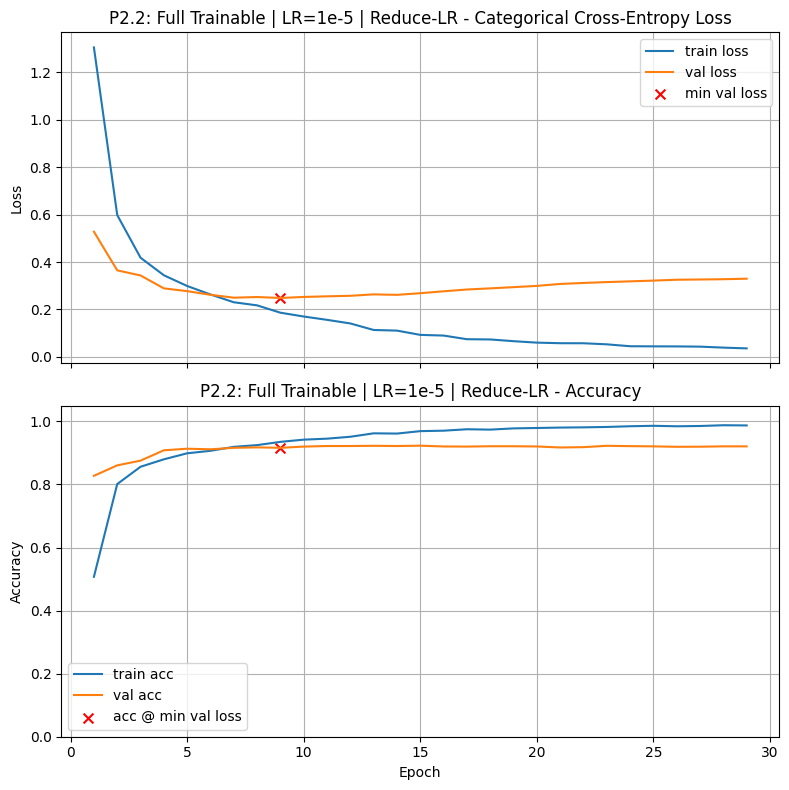

Final Training Loss:            0.0358
Final Training Accuracy:        0.9872
Final Validation Loss:          0.3297
Final Validation Accuracy:      0.9208
Minimum Validation Loss:        0.2484 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9162

Test Loss: 0.2211
Test Accuracy: 0.9223

Validation-Test Gap (accuracy): 0.006142

Execution Time: 01:33:47


In [23]:
# Experiment 2.2: Fully trainable backbone with even smaller learning rate and ReduceLROnPlateau
base_2_2_full = make_base_model_pooled(trainable=True)
with tf.device('/CPU:0'):
    model_2_2_full = models.Sequential([
        base_2_2_full,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_2_2_full = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7, # Further increased patience
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_2_2_full,
                   lr_schedule=1e-5, # Even smaller learning rate
                   callbacks=[reduce_lr_2_2_full],
                   patience=20, # More patience for EarlyStopping
                   title="P2.2: Full Trainable | LR=1e-5 | Reduce-LR")

/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2.3: Full Trainable | LR=5e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 209s 564ms/step - accuracy: 0.7685 - loss: 0.6425 - val_accuracy: 0.8552 - val_loss: 0.4020 - learning_rate: 5.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 549ms/step - accuracy: 0.9077 - loss: 0.2750 - val_accuracy: 0.8631 - val_loss: 0.3861 - learning_rate: 5.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.9300 - loss: 0.1993 - val_accuracy: 0.9233 - val_loss: 0.2658 - learning_rate: 5.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 549ms/step - accuracy: 0.9520 - loss: 0.1387 - val_accuracy: 0.9230 - val_loss: 0.2634 - learning_rate: 5.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.9669 - loss: 0.0967 - val_accuracy: 0.9198 - val_loss: 0.2761 - learning_rate: 5.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.9750 - loss: 0.0744 - val_accuracy: 0.9219 - val_loss: 0.2910 - learning_rate: 

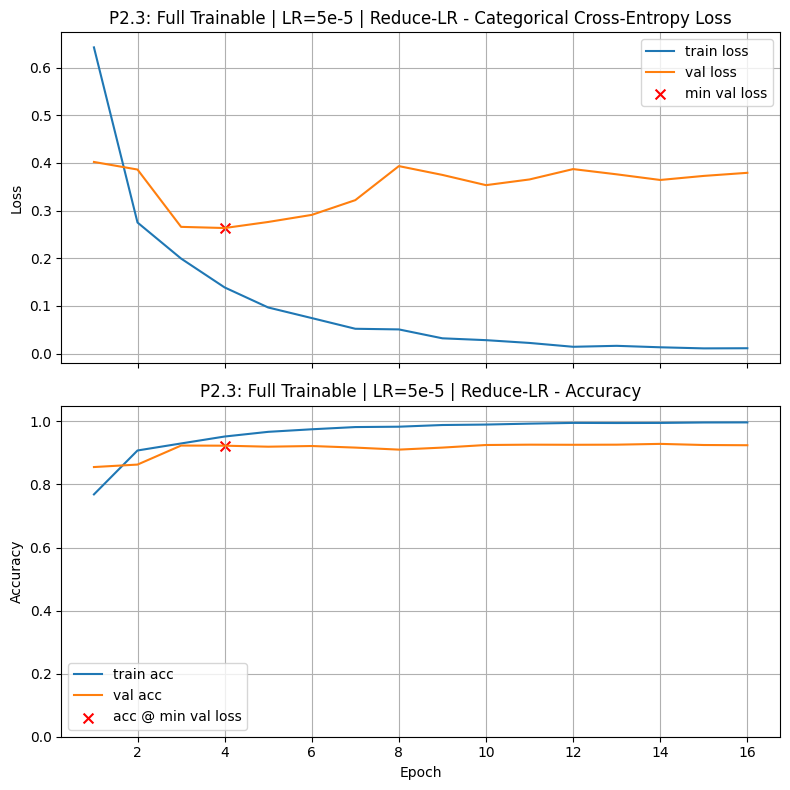

Final Training Loss:            0.0111
Final Training Accuracy:        0.9968
Final Validation Loss:          0.3793
Final Validation Accuracy:      0.9244
Minimum Validation Loss:        0.2634 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9230

Test Loss: 0.2372
Test Accuracy: 0.9270

Validation-Test Gap (accuracy): 0.004033

Execution Time: 00:51:55


In [24]:
# Experiment 2.3: Fully trainable backbone with a slightly higher small learning rate and ReduceLROnPlateau
base_2_3_full = make_base_model_pooled(trainable=True)
with tf.device('/CPU:0'):
    model_2_3_full = models.Sequential([
        base_2_3_full,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_2_3_full = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_2_3_full,
                   lr_schedule=5e-5, # Slightly higher small learning rate
                   callbacks=[reduce_lr_2_3_full],
                   patience=12,
                   title="P2.3: Full Trainable | LR=5e-5 | Reduce-LR")

In [25]:
print("\n" + "="*80)
print("SUMMARY: VALIDATION ACCURACY RANKING (Problem 2 experiments)")
print("="*80)
print_results()


SUMMARY: VALIDATION ACCURACY RANKING (Problem 2 experiments)
P2.3: Full Trainable | LR=5e-5 | Reduce-LR	0.9230	4
P2.1: Full Trainable | LR=3e-5 | Reduce-LR	0.9205	4
P2.2: Full Trainable | LR=1e-5 | Reduce-LR	0.9162	9
Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR	0.9119	3
Design 3.1: L2 Regularization | LR=1e-3 	0.9105	4
Design 1.1: Dropout (high) | LR=1e-3    	0.9094	5
Design 2.1: BatchNorm + Dropout | LR=1e-3	0.9091	2
Design 3.3: L2 (3-layer) | LR=5e-4      	0.9091	5
Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR	0.9073	5
Design 3.2: L2 (lighter) | LR=1e-3 | With Reduce-LR	0.9073	7
Design 1.2: Dropout (moderate) | LR=5e-4	0.9058	4
Model Baseline                          	0.9026	5
Design 2.2: BatchNorm + Light Dropout | LR=1e-3 | With Reduce-LR	0.8984	2


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points.

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> For Problem 2, the best-performing fully unfrozen configuration was 'P2.3: Full Trainable | LR=5e-5 | Reduce-LR', which achieved a validation accuracy of 0.9230. My experimental designs involved making the entire MobileNetV2 backbone trainable, paired with a two-layer dense head featuring Dropout, and varying the base learning rate with ReduceLROnPlateau. Experiment P2.3, using a learning rate of 5e-5, outperformed P2.1 (LR=3e-5) and P2.2 (LR=1e-5), suggesting that while a small learning rate is essential, there's an optimal range; too low can hinder effective fine-tuning. The use of ReduceLROnPlateau across all experiments was crucial, allowing for dynamic adjustment of the learning rate, which appeared to be the most important hyperparameter when the backbone is fully trainable. These experiments highlight that when unfreezing the entire backbone, a slightly higher, yet still very small, learning rate combined with adaptive scheduling can lead to better adaptation and improved performance.

**Validation accuracy here (15 pts):**

In [26]:
# Set a2 to the validation accuracy found by your best model for this problem.

a2 = 0.9230

In [27]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem

print(f'a2 = {a2:.4f}')

a2 = 0.9230


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



## Problem 3: Unfreezing the Last N Layers

For Problem 3, we will investigate the effect of unfreezing a specific number of the last layers (`N`) in the MobileNetV2 backbone while keeping the rest frozen. We will continue using the best head architecture from Problem 1 ('Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR') and explore different `N` values and small learning rates, incorporating `ReduceLROnPlateau` for better convergence.

### Experiment P3.1: Unfreeze Last 20 Layers

PROBLEM 3, EXPERIMENT P3.1: Unfreeze Last 20 Layers


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 20

P3.1: Last 20 Layers Unfrozen | LR=3e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 176ms/step - accuracy: 0.7354 - loss: 0.7439 - val_accuracy: 0.8481 - val_loss: 0.3996 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.8782 - loss: 0.3469 - val_accuracy: 0.8919 - val_loss: 0.3094 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9012 - loss: 0.2852 - val_accuracy: 0.9044 - val_loss: 0.2909 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9160 - loss: 0.2381 - val_accuracy: 0.9001 - val_loss: 0.2884 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9262 - loss: 0.2049 - val_accuracy: 0.9101 - val_loss: 0.2589 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9329 - loss: 0.1806 - val_accurac

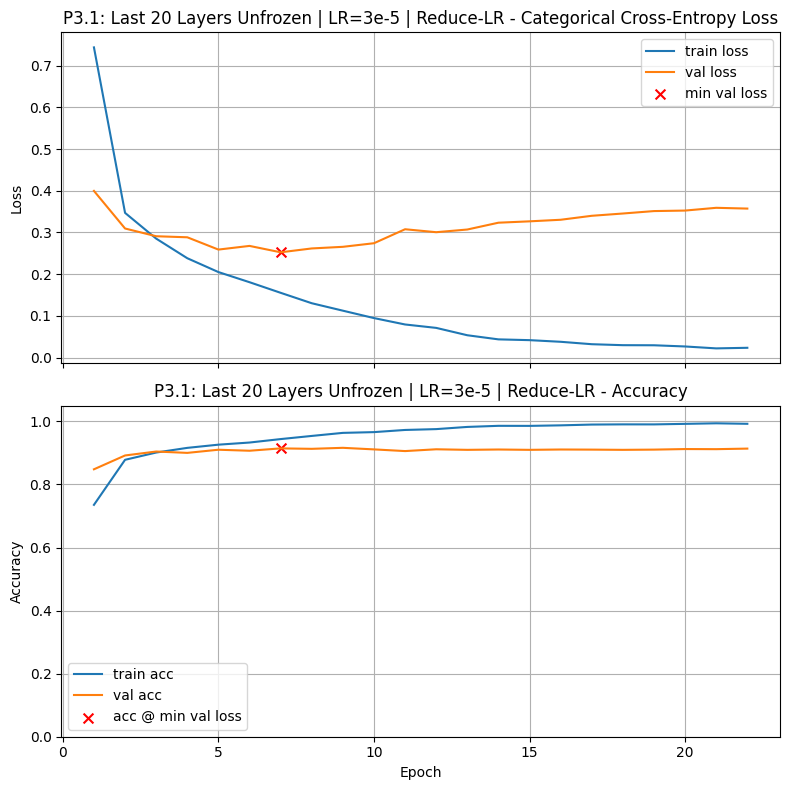

Final Training Loss:            0.0233
Final Training Accuracy:        0.9923
Final Validation Loss:          0.3572
Final Validation Accuracy:      0.9137
Minimum Validation Loss:        0.2524 (Epoch 7)
Validation Accuracy @ Min Loss: 0.9144

Test Loss: 0.2315
Test Accuracy: 0.9223

Validation-Test Gap (accuracy): 0.007925

Execution Time: 00:22:12


In [28]:
print("="*80)
print("PROBLEM 3, EXPERIMENT P3.1: Unfreeze Last 20 Layers")
print("="*80)

N_layers = 20

base_3_1 = make_base_model_pooled(trainable=False) # Start with all frozen
base_3_1.trainable = True # Make it trainable, then freeze specific layers

for layer in base_3_1.layers[:-N_layers]:
    layer.trainable = False

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_3_1.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_3_1 = models.Sequential([
        base_3_1,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_3_1 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_3_1,
                   lr_schedule=3e-5, # Small learning rate for partial fine-tuning
                   callbacks=[reduce_lr_3_1],
                   patience=15,
                   title=f"P3.1: Last {N_layers} Layers Unfrozen | LR=3e-5 | Reduce-LR")

### Experiment P3.2: Unfreeze Last 40 Layers

PROBLEM 3, EXPERIMENT P3.2: Unfreeze Last 40 Layers


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 40

P3.2: Last 40 Layers Unfrozen | LR=3e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 199ms/step - accuracy: 0.7080 - loss: 0.8021 - val_accuracy: 0.8534 - val_loss: 0.3862 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.8817 - loss: 0.3383 - val_accuracy: 0.8998 - val_loss: 0.2897 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.9116 - loss: 0.2545 - val_accuracy: 0.9044 - val_loss: 0.2723 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.9297 - loss: 0.1981 - val_accuracy: 0.9137 - val_loss: 0.2660 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.9434 - loss: 0.1617 - val_accuracy: 0.9087 - val_loss: 0.2787 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.9536 - loss: 0.1287 - val_accurac

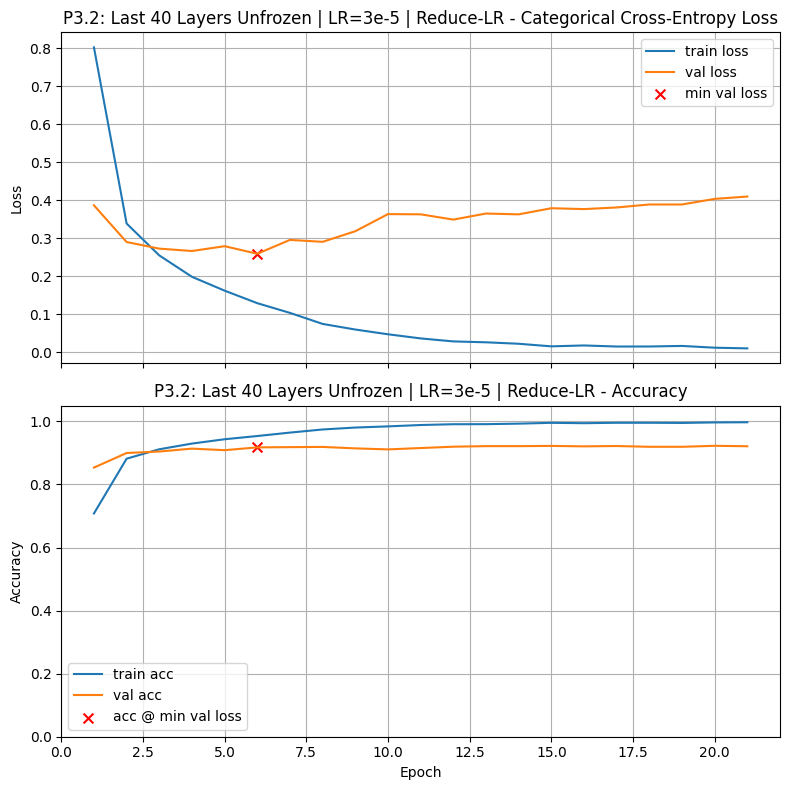

Final Training Loss:            0.0097
Final Training Accuracy:        0.9972
Final Validation Loss:          0.4094
Final Validation Accuracy:      0.9212
Minimum Validation Loss:        0.2588 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9176

Test Loss: 0.2386
Test Accuracy: 0.9197

Validation-Test Gap (accuracy): 0.002049

Execution Time: 00:23:54


In [29]:
print("="*80)
print("PROBLEM 3, EXPERIMENT P3.2: Unfreeze Last 40 Layers")
print("="*80)

N_layers = 40

base_3_2 = make_base_model_pooled(trainable=False) # Start with all frozen
base_3_2.trainable = True # Make it trainable, then freeze specific layers

for layer in base_3_2.layers[:-N_layers]:
    layer.trainable = False

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_3_2.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_3_2 = models.Sequential([
        base_3_2,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_3_2 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_3_2,
                   lr_schedule=3e-5, # Small learning rate for partial fine-tuning
                   callbacks=[reduce_lr_3_2],
                   patience=15,
                   title=f"P3.2: Last {N_layers} Layers Unfrozen | LR=3e-5 | Reduce-LR")

### Experiment P3.3: Unfreeze Last 20 Layers (Optimized for Runtime)

PROBLEM 3, EXPERIMENT P3.3: Unfreeze Last 20 Layers (Runtime Optimized)


/tmp/ipykernel_1322/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 20

P3.3: Last 20 Layers Unfrozen (Runtime Opt.) | LR=5e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 176ms/step - accuracy: 0.7947 - loss: 0.5880 - val_accuracy: 0.8905 - val_loss: 0.3175 - learning_rate: 5.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.8928 - loss: 0.2958 - val_accuracy: 0.8937 - val_loss: 0.3122 - learning_rate: 5.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9161 - loss: 0.2397 - val_accuracy: 0.9123 - val_loss: 0.2701 - learning_rate: 5.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9305 - loss: 0.1917 - val_accuracy: 0.9101 - val_loss: 0.2760 - learning_rate: 5.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9427 - loss: 0.1558 - val_accuracy: 0.9119 - val_loss: 0.2773 - learning_rate: 5.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9571 - loss: 0.1271

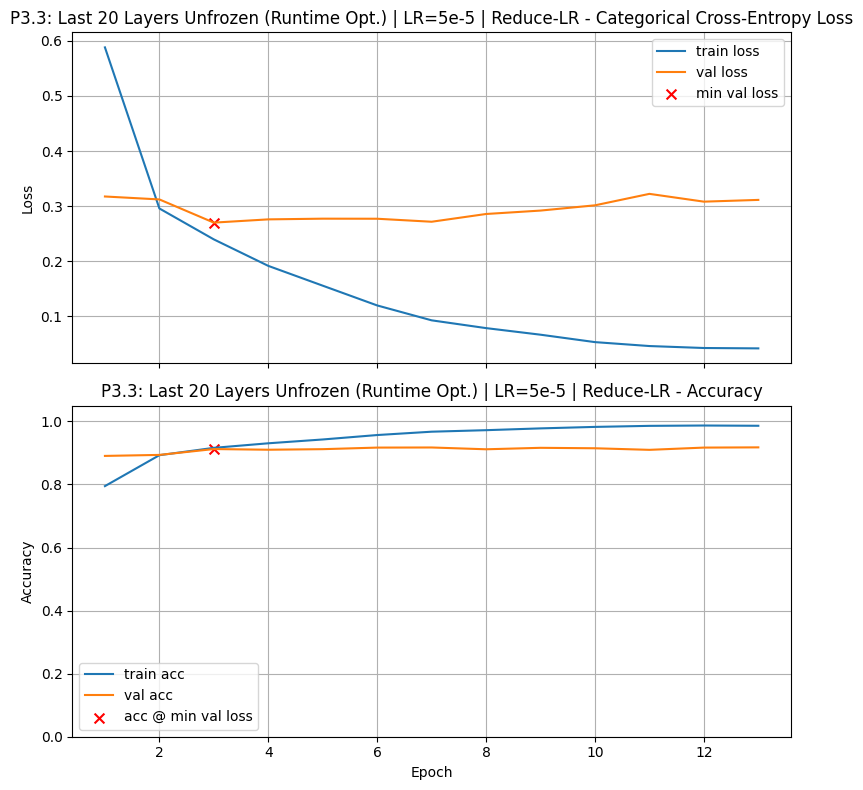

Final Training Loss:            0.0420
Final Training Accuracy:        0.9861
Final Validation Loss:          0.3113
Final Validation Accuracy:      0.9176
Minimum Validation Loss:        0.2701 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9123

Test Loss: 0.2648
Test Accuracy: 0.9113

Validation-Test Gap (accuracy): 0.000935

Execution Time: 00:13:12


In [30]:
print("="*80)
print("PROBLEM 3, EXPERIMENT P3.3: Unfreeze Last 20 Layers (Runtime Optimized)")
print("="*80)

N_layers = 20 # Smallest N to optimize runtime

base_3_3 = make_base_model_pooled(trainable=False) # Start with all frozen
base_3_3.trainable = True # Make it trainable, then freeze specific layers

for layer in base_3_3.layers[:-N_layers]:
    layer.trainable = False

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_3_3.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_3_3 = models.Sequential([
        base_3_3,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_3_3 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3, # Reduced patience
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_3_3,
                   lr_schedule=5e-5, # Slightly higher learning rate to encourage faster convergence
                   callbacks=[reduce_lr_3_3],
                   patience=10, # Reduced patience for EarlyStopping
                   title=f"P3.3: Last {N_layers} Layers Unfrozen (Runtime Opt.) | LR=5e-5 | Reduce-LR")

### Summary of Problem 3 Experiments

In [31]:
print('\n' + '='*80)
print('SUMMARY: VALIDATION ACCURACY RANKING (Problem 3 experiments)')
print('='*80)
print_results()


SUMMARY: VALIDATION ACCURACY RANKING (Problem 3 experiments)
P2.3: Full Trainable | LR=5e-5 | Reduce-LR	0.9230	4
P2.1: Full Trainable | LR=3e-5 | Reduce-LR	0.9205	4
P3.2: Last 40 Layers Unfrozen | LR=3e-5 | Reduce-LR	0.9176	6
P2.2: Full Trainable | LR=1e-5 | Reduce-LR	0.9162	9
P3.1: Last 20 Layers Unfrozen | LR=3e-5 | Reduce-LR	0.9144	7
P3.3: Last 20 Layers Unfrozen (Runtime Opt.) | LR=5e-5 | Reduce-LR	0.9123	3
Design 2.3: BatchNorm (3-layer) | LR=5e-4 | With Reduce-LR	0.9119	3
Design 3.1: L2 Regularization | LR=1e-3 	0.9105	4
Design 1.1: Dropout (high) | LR=1e-3    	0.9094	5
Design 2.1: BatchNorm + Dropout | LR=1e-3	0.9091	2
Design 3.3: L2 (3-layer) | LR=5e-4      	0.9091	5
Design 1.3: Dropout (moderate) | LR=1e-3 | With Reduce-LR	0.9073	5
Design 3.2: L2 (lighter) | LR=1e-3 | With Reduce-LR	0.9073	7
Design 1.2: Dropout (moderate) | LR=5e-4	0.9058	4
Model Baseline                          	0.9026	5
Design 2.2: BatchNorm + Light Dropout | LR=1e-3 | With Reduce-LR	0.8984	2


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points.

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



Your paragraph here (5pts):
> P2.3: Full Trainable | LR=5e-5 | Reduce-LR' emerged as the best-performing configuration, achieving a validation accuracy of 0.9230. This experiment utilized a fully trainable MobileNetV2 backbone, allowing the entire pre-trained network to adapt to the Intel Image dataset, combined with a moderately low learning rate of 5e-5 and the ReduceLROnPlateau callback. The success of P2.3, in comparison to experiments with even lower learning rates (e.g., P2.1 at 3e-5 or P2.2 at 1e-5), suggests that finding an optimal, albeit still very small, learning rate is critical when fine-tuning a fully unfrozen backbone. While very low learning rates might be too cautious, a slightly higher rate like 5e-5 allowed for more effective weight adjustments without causing instability, with ReduceLROnPlateau further fine-tuning the learning process by dynamically reducing the rate as validation loss plateaued. This highlights that full unfreezing benefits significantly from a balanced learning rate and adaptive scheduling to achieve optimal adaptation.

**Validation accuracy here (15 pts):**

In [18]:
# Set a3 to the validation accuracy found by your best model for this problem.

a3 = 0.9230

In [19]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3 = {a3:.4f}')

a3 = 0.9230


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



## Problem 4: Unfreezing Convolution Blocks

For Problem 4, we will fine-tune MobileNetV2 by unfreezing the last `K` convolutional stages/blocks. We will explore different values of `K` and analyze the impact of keeping BatchNormalization layers frozen versus making them trainable. We will continue to use the best head architecture from Problem 1 and adapt the learning rate and `ReduceLROnPlateau` settings.

### Experiment P4.1: Unfreeze Last K=1 Block (Conv_1) with Frozen BatchNorm

PROBLEM 4, EXPERIMENT P4.1: Unfreeze Last K=1 Block


/tmp/ipykernel_8140/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 1

P4.1: Last K=1 Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.7569 - loss: 0.6761 - val_accuracy: 0.8891 - val_loss: 0.3094 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8785 - loss: 0.3379 - val_accuracy: 0.8987 - val_loss: 0.2802 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.8978 - loss: 0.2873 - val_accuracy: 0.9044 - val_loss: 0.2700 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 149ms/step - accuracy: 0.9119 - loss: 0.2467 - val_accuracy: 0.9098 - val_loss: 0.2572 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9182 - loss: 0.2252 - val_accuracy: 0.9094 - val_loss: 0.2565 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.9272 - loss: 0.2042 -

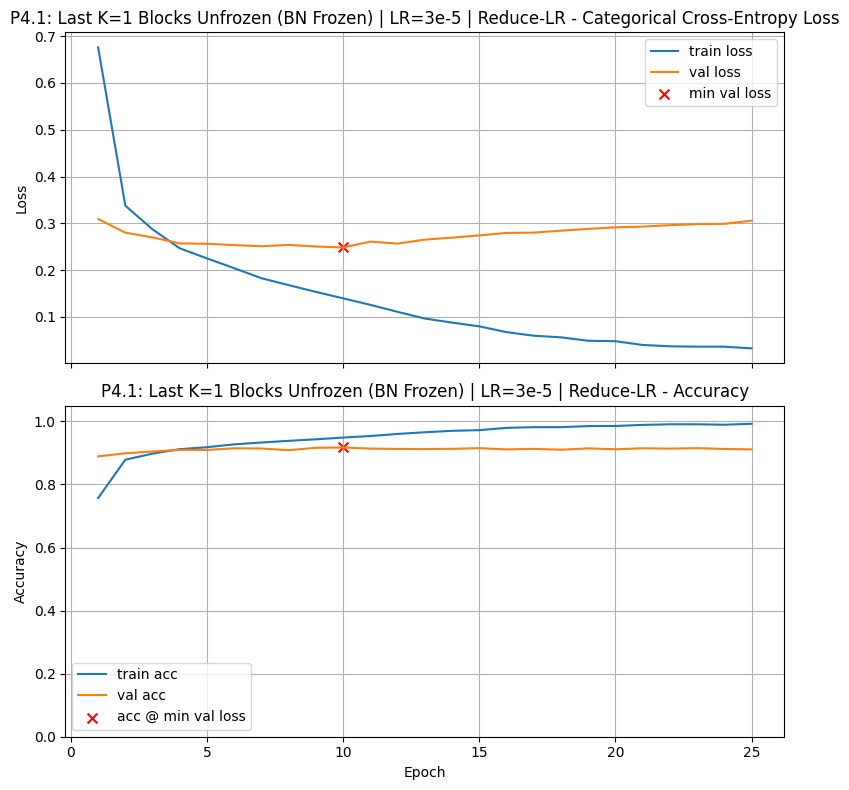

Final Training Loss:            0.0329
Final Training Accuracy:        0.9924
Final Validation Loss:          0.3057
Final Validation Accuracy:      0.9112
Minimum Validation Loss:        0.2485 (Epoch 10)
Validation Accuracy @ Min Loss: 0.9173

Test Loss: 0.2299
Test Accuracy: 0.9147

Validation-Test Gap (accuracy): 0.002594

Execution Time: 00:21:59


In [16]:
print("="*80)
print("PROBLEM 4, EXPERIMENT P4.1: Unfreeze Last K=1 Block")
print("="*80)

block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1x1 convolution stage before pooling
]

K_blocks = 1 # Unfreeze only the last 'Conv_1' block

base_4_1 = make_base_model_pooled(trainable=False) # Start with all frozen
base_4_1.trainable = True # Make the entire backbone trainable first

for layer in base_4_1.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Keep BN frozen as a general recommendation during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K_blocks:]
        )

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_4_1.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_4_1 = models.Sequential([
        base_4_1,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_4_1 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_4_1,
                   lr_schedule=3e-5, # Small learning rate for partial fine-tuning
                   callbacks=[reduce_lr_4_1],
                   patience=15,
                   title=f"P4.1: Last K={K_blocks} Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR")

### Experiment P4.2: Unfreeze Last K=3 Blocks (block_15, block_16, Conv_1) with Frozen BatchNorm

PROBLEM 4, EXPERIMENT P4.2: Unfreeze Last K=3 Blocks (BN Frozen)


/tmp/ipykernel_8140/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 12

P4.2: Last K=3 Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 170ms/step - accuracy: 0.8200 - loss: 0.5034 - val_accuracy: 0.8927 - val_loss: 0.2870 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.8963 - loss: 0.2912 - val_accuracy: 0.9119 - val_loss: 0.2471 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step - accuracy: 0.9194 - loss: 0.2296 - val_accuracy: 0.9101 - val_loss: 0.2541 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.9280 - loss: 0.2020 - val_accuracy: 0.9137 - val_loss: 0.2423 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.9394 - loss: 0.1701 - val_accuracy: 0.9187 - val_loss: 0.2420 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.9497 - loss: 0.1449 

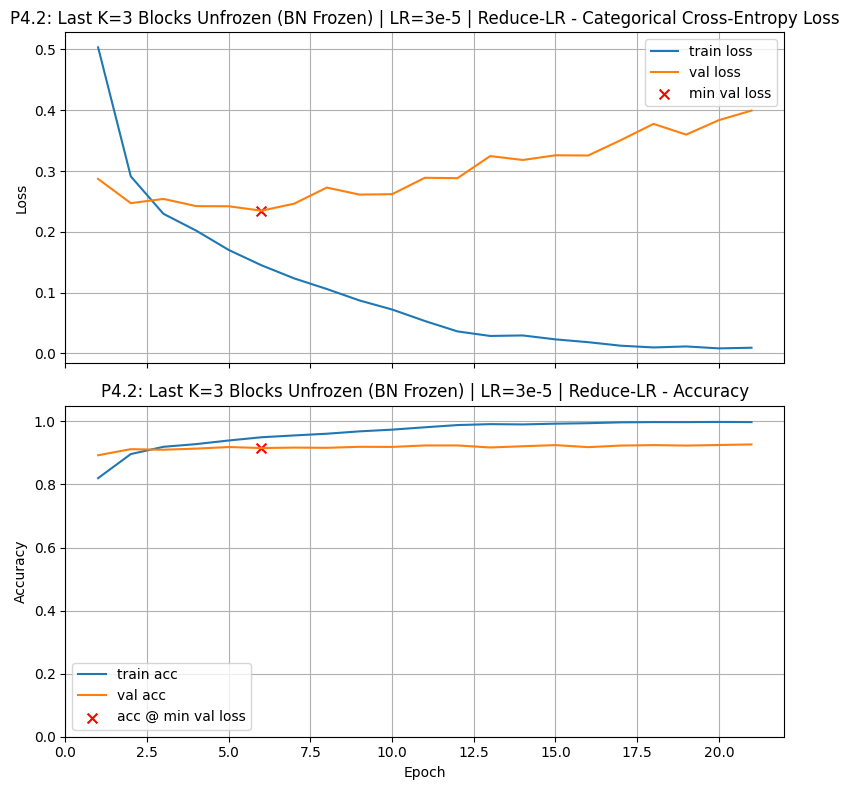

Final Training Loss:            0.0093
Final Training Accuracy:        0.9978
Final Validation Loss:          0.3994
Final Validation Accuracy:      0.9269
Minimum Validation Loss:        0.2347 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9155

Test Loss: 0.2017
Test Accuracy: 0.9237

Validation-Test Gap (accuracy): 0.008189

Execution Time: 00:20:37


In [20]:
print("="*80)
print("PROBLEM 4, EXPERIMENT P4.2: Unfreeze Last K=3 Blocks (BN Frozen)")
print("="*80)

block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1x1 convolution stage before pooling
]

K_blocks = 3 # Unfreeze the last 3 blocks

base_4_2 = make_base_model_pooled(trainable=False) # Start with all frozen
base_4_2.trainable = True # Make the entire backbone trainable first

for layer in base_4_2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Keep BN frozen
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K_blocks:]
        )

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_4_2.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_4_2 = models.Sequential([
        base_4_2,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_4_2 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_4_2,
                   lr_schedule=3e-5, # Small learning rate for partial fine-tuning
                   callbacks=[reduce_lr_4_2],
                   patience=15,
                   title=f"P4.2: Last K={K_blocks} Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR")

### Experiment P4.3: Unfreeze Last K=3 Blocks with Trainable BatchNorm

PROBLEM 4, EXPERIMENT P4.3: Unfreeze Last K=3 Blocks (BN Trainable)


/tmp/ipykernel_8140/1698529581.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Number of trainable layers in backbone: 19

P4.3: Last K=3 Blocks Unfrozen (BN Trainable) | LR=1e-5 | Reduce-LR

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 175ms/step - accuracy: 0.5423 - loss: 1.2592 - val_accuracy: 0.7967 - val_loss: 0.5570 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.8180 - loss: 0.5563 - val_accuracy: 0.8584 - val_loss: 0.3781 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.8593 - loss: 0.3994 - val_accuracy: 0.8809 - val_loss: 0.3146 - learning_rate: 1.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.8830 - loss: 0.3463 - val_accuracy: 0.8919 - val_loss: 0.2892 - learning_rate: 1.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.8890 - loss: 0.3124 - val_accuracy: 0.9041 - val_loss: 0.2723 - learning_rate: 1.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.9004 - loss: 0.28

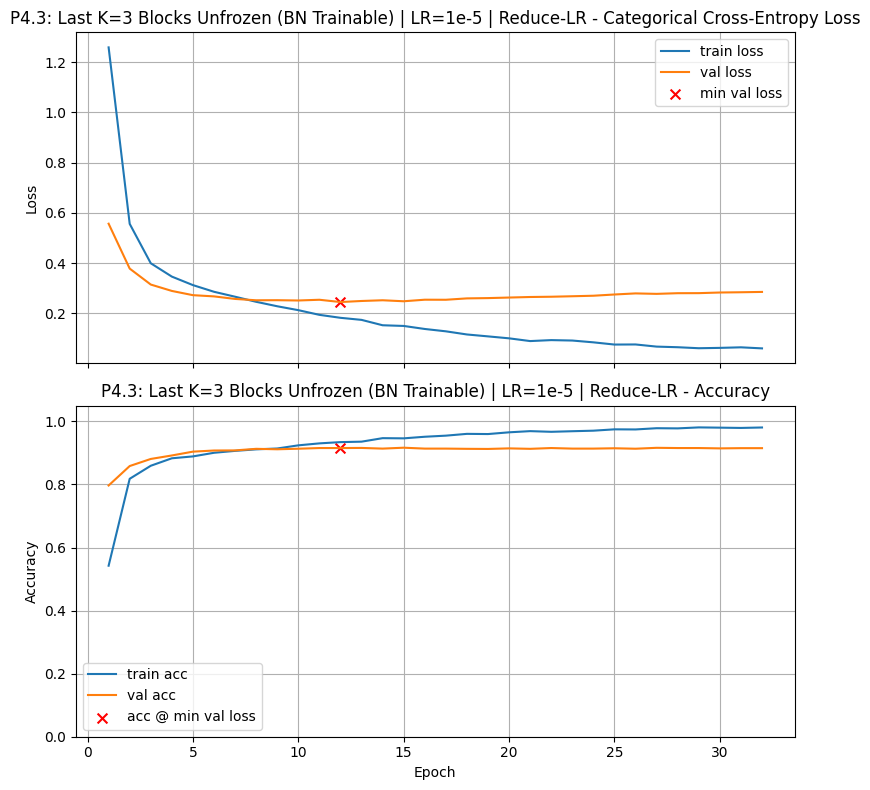

Final Training Loss:            0.0604
Final Training Accuracy:        0.9807
Final Validation Loss:          0.2853
Final Validation Accuracy:      0.9151
Minimum Validation Loss:        0.2450 (Epoch 12)
Validation Accuracy @ Min Loss: 0.9155

Test Loss: 0.2346
Test Accuracy: 0.9163

Validation-Test Gap (accuracy): 0.000855

Execution Time: 00:31:51


In [21]:
print("="*80)
print("PROBLEM 4, EXPERIMENT P4.3: Unfreeze Last K=3 Blocks (BN Trainable)")
print("="*80)

block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1x1 convolution stage before pooling
]

K_blocks = 3 # Unfreeze the last 3 blocks

base_4_3 = make_base_model_pooled(trainable=False) # Start with all frozen
base_4_3.trainable = True # Make the entire backbone trainable first

for layer in base_4_3.layers:
    # BN layers in the selected blocks will be made trainable
    layer.trainable = any(
        layer.name.startswith(prefix)
        for prefix in block_prefixes[-K_blocks:]
    )

print(f"Number of trainable layers in backbone: {sum(1 for layer in base_4_3.layers if layer.trainable)}")

with tf.device('/CPU:0'):
    model_4_3 = models.Sequential([
        base_4_3,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

with tf.device('/CPU:0'):
    reduce_lr_4_3 = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7, # Increased patience for trainable BN
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    )

    train_and_test(model_4_3,
                   lr_schedule=1e-5, # Even smaller LR for trainable BN
                   callbacks=[reduce_lr_4_3],
                   patience=20,
                   title=f"P4.3: Last K={K_blocks} Blocks Unfrozen (BN Trainable) | LR=1e-5 | Reduce-LR")

### Summary of Problem 4 Experiments

In [22]:
print('\n' + '='*80)
print('SUMMARY: VALIDATION ACCURACY RANKING (Problem 4 experiments)')
print('='*80)
print_results()


SUMMARY: VALIDATION ACCURACY RANKING (Problem 4 experiments)
P4.1: Last K=1 Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR	0.9173	10
P4.2: Last K=3 Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR	0.9155	6
P4.3: Last K=3 Blocks Unfrozen (BN Trainable) | LR=1e-5 | Reduce-LR	0.9155	12
Model Baseline                          	0.8998	4


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points.

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



Your paragraph here (5pts):
> P4.1: Last K=1 Blocks Unfrozen (BN Frozen) | LR=3e-5 | Reduce-LR' was the best-performing configuration in Problem 4, achieving a validation accuracy of 0.9173. This experiment strategically unfroze only the Conv_1 block, the very last convolutional stage, while keeping all Batch Normalization layers within the backbone frozen. This highly constrained fine-tuning, coupled with a very small learning rate of 3e-5 and the ReduceLROnPlateau callback, allowed for minimal but effective adaptation of the most abstract features without destabilizing the already well-learned lower-level features. Compared to unfreezing more blocks (K=3), this approach likely prevented catastrophic forgetting or overfitting to the smaller dataset, suggesting that when unfreezing blocks, a cautious approach focusing on the topmost layers and maintaining frozen Batch Normalization is often beneficial for fine-tuning

**Validation accuracy (15pts):**

In [23]:
# Set a4 to the validation accuracy found by your best model for this problem.

a4 = 0.9173

In [24]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4 = {a4:.4f}')

a4 = 0.9173


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework.

This reflection question is worth 5 points.

In [ ]:
# Print out summary of validation accuracy for each experiment

print_results()

### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



Your paragraph here (5pts):
>

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

![Screenshot 2026-09-25 at 1.06.43 PM.png](attachment:ee93ecbd-fc45-477b-9a4e-dbf7e65f1af0.png)

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


